# Notebook 18 — Fusion Model: Single-Image Inference / Demo

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
from pathlib import Path
from collections import defaultdict
import numpy as np, pandas as pd
from PIL import Image
import torch, torch.nn as nn
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import matplotlib.pyplot as plt

DEVICE = (torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print(f"Using device: {DEVICE}")

Using device: mps


## SET The Image

In [9]:
# Point this at the cropped medicine-name image you want to recognise.
IMAGE_PATH = "../data/pharmacy_lk/images/173443_0_med_1.jpg"  

# config / paths
DATA_ROOT   = Path("../data/pharmacy_lk")
TRAIN_CSV   = DATA_ROOT / "splits/train.csv"
LABEL_COL   = "medicine_name"
CRNN_CKPT   = Path("../checkpoints/baseline_crnn_v2/best.pt")
TROCR_CKPT  = Path("../checkpoints/benchmark_trocr/best")
PROC_NAME   = "microsoft/trocr-small-handwritten"
IMG_H, IMG_W = 48, 320
RNN_HIDDEN, RNN_LAYERS, DROPOUT = 256, 2, 0.2
LEX_TAU = 0.6

## 1. Lexicon (training names) + helpers

In [3]:
def edit_distance(a, b):
    if a == b: return 0
    if not a: return len(b)
    if not b: return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        curr = [i]
        for j, cb in enumerate(b, 1):
            curr.append(min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = curr
    return prev[-1]

lexicon = set(pd.read_csv(TRAIN_CSV)[LABEL_COL].astype(str).str.strip().str.lower())
LEXSET = lexicon
by_len = defaultdict(list)
for w in sorted(lexicon): by_len[len(w)].append(w)
print(f"lexicon: {len(lexicon)} medicine names")

def nearest(word, gap=3):
    if not word: return None, 10**9
    if word in by_len.get(len(word), ()): return word, 0
    best, bd = None, 10**9
    for L in range(len(word)-gap, len(word)+gap+1):
        for e in by_len.get(L, ()):
            d = edit_distance(word, e)
            if d < bd: best, bd = e, d
            if bd == 1: return best, bd
    return best, bd

def lex_snap(word, tau=LEX_TAU):
    e, d = nearest(word)
    return e if (e is not None and d / max(len(word), 1) <= tau) else word

lexicon: 1210 medicine names


## 2. Load CRNN

In [4]:
class Vocab:
    BLANK = 0
    def __init__(self, texts):
        chars = sorted(set("".join(texts)))
        self.idx2char = {i + 1: c for i, c in enumerate(chars)}
        self.char2idx = {c: i for i, c in self.idx2char.items()}
    def __len__(self): return len(self.idx2char) + 1
    def decode_conf(self, log_probs_row):
        probs = log_probs_row.exp(); idx = log_probs_row.argmax(-1).tolist()
        out, prev, confs = [], None, []
        for t, i in enumerate(idx):
            if i != prev and i != self.BLANK:
                out.append(self.idx2char[i]); confs.append(float(probs[t, i]))
            prev = i
        return "".join(out), (float(np.mean(confs)) if confs else 0.0)

class CRNN(nn.Module):
    def __init__(self, n, rnn_hidden=256, rnn_layers=2, dropout=0.2):
        super().__init__()
        def conv(i, o, bn=False):
            L = [nn.Conv2d(i, o, 3, 1, 1)]
            if bn: L.append(nn.BatchNorm2d(o))
            L.append(nn.ReLU(inplace=True)); return L
        self.cnn = nn.Sequential(*conv(1,64), nn.MaxPool2d(2,2), *conv(64,128), nn.MaxPool2d(2,2),
            *conv(128,256), *conv(256,256), nn.MaxPool2d((2,1),(2,1)),
            *conv(256,512,bn=True), *conv(512,512,bn=True), nn.MaxPool2d((2,1),(2,1)))
        self.collapse = nn.AdaptiveAvgPool2d((1, None))
        self.rnn = nn.LSTM(512, rnn_hidden, rnn_layers, bidirectional=True,
                           dropout=dropout if rnn_layers > 1 else 0.0)
        self.head = nn.Linear(2*rnn_hidden, n)
    def forward(self, x):
        f = self.collapse(self.cnn(x)).squeeze(2).permute(2, 0, 1)
        seq, _ = self.rnn(f); return self.head(seq)

_train_labels = pd.read_csv(TRAIN_CSV)[LABEL_COL].dropna().astype(str).str.strip().tolist()
VOCAB = Vocab(_train_labels)
ck = torch.load(CRNN_CKPT, map_location="cpu")
assert len(VOCAB) == ck["model"]["head.bias"].shape[0], "CRNN vocab/checkpoint mismatch"
crnn = CRNN(len(VOCAB), RNN_HIDDEN, RNN_LAYERS, DROPOUT)
crnn.load_state_dict(ck["model"]); crnn.to(DEVICE).eval()
print("CRNN loaded")

def crnn_predict(pil_img):
    img = pil_img.convert("L"); w, h = img.size
    nw = min(max(1, int(round(w*IMG_H/h))), IMG_W)
    img = img.resize((nw, IMG_H), Image.BILINEAR)
    canvas = Image.new("L", (IMG_W, IMG_H), 255); canvas.paste(img, (0,0))
    x = torch.from_numpy(np.array(canvas, dtype=np.float32)/255.0).unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        lp = crnn(x.to(DEVICE)).log_softmax(-1).permute(1,0,2)[0].cpu()
    raw, conf = VOCAB.decode_conf(lp)
    return raw, conf

CRNN loaded


## 3. Load TrOCR

In [5]:
processor = TrOCRProcessor.from_pretrained(PROC_NAME)
trocr = VisionEncoderDecoderModel.from_pretrained(TROCR_CKPT).to(DEVICE).eval()
print("TrOCR loaded")

def trocr_predict(pil_img):
    pv = processor(pil_img.convert("RGB"), return_tensors="pt").pixel_values.to(DEVICE)
    with torch.no_grad():
        out = trocr.generate(pv, max_new_tokens=24, output_scores=True, return_dict_in_generate=True)
    ts = trocr.compute_transition_scores(out.sequences, out.scores, normalize_logits=True)
    text = processor.decode(out.sequences[0], skip_special_tokens=True).strip().lower()
    valid = ts[0][torch.isfinite(ts[0])]
    conf = float(valid.mean().exp()) if valid.numel() else 0.0
    return text, conf

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

TrOCR loaded


## 4. The FUSION referee (your proposed model)
TrOCR-anchored: start from TrOCR+lexicon; override with CRNN's answer ONLY when the CRNN
produced a confirmed exact lexicon match that TrOCR (snapped) did not.

In [10]:
def fusion_predict(pil_img, verbose=True):
    c_raw, c_conf = crnn_predict(pil_img)
    t_raw, t_conf = trocr_predict(pil_img)
    c_lex = lex_snap(c_raw)              # CRNN + lexicon
    t_lex = lex_snap(t_raw)              # TrOCR + lexicon (the base)
    if (c_lex in LEXSET) and (t_lex not in LEXSET):
        final, source = c_lex, "CRNN+lexicon (rescued a name TrOCR missed)"
    else:
        final, source = t_lex, "TrOCR+lexicon (base)"
    if verbose:
        print(f"  CRNN raw      : {c_raw!r}  (conf {c_conf:.2f})  -> +lexicon: {c_lex!r}")
        print(f"  TrOCR raw     : {t_raw!r}  (conf {t_conf:.2f})  -> +lexicon: {t_lex!r}")
        print(f"  referee chose : {source}")
    return final

## 5. Run it on YOUR image

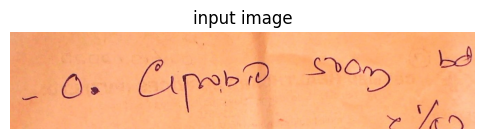

Running FUSION model...

  CRNN raw      : 'ciprobin'  (conf 0.54)  -> +lexicon: 'ciprobid'
  TrOCR raw     : 'calboral'  (conf 0.66)  -> +lexicon: 'calboral'
  referee chose : TrOCR+lexicon (base)

  PREDICTED MEDICINE NAME:  calboral


In [11]:
img_path = Path(IMAGE_PATH)
if not img_path.exists():
    print(f"!! Image not found: {img_path}")
    print("   Edit IMAGE_PATH in section 0 to point at a real image file.")
else:
    pil = Image.open(img_path)
    plt.figure(figsize=(6, 2.2)); plt.imshow(pil, cmap="gray"); plt.axis("off")
    plt.title("input image"); plt.show()
    print("Running FUSION model...\n")
    prediction = fusion_predict(pil, verbose=True)
    print("\n" + "="*50)
    print(f"  PREDICTED MEDICINE NAME:  {prediction}")
    print("="*50)

## 6.Batch test several images
Put a few image paths in the list to test them all at once.

In [12]:
BATCH_IMAGES = [
    "../data/pharmacy_lk/images/173109_0_med_7.jpg",
    "../data/pharmacy_lk/images/173233_0_med_1.jpg",
]
for p in BATCH_IMAGES:
    pp = Path(p)
    if pp.exists():
        print(f"\n--- {pp.name} ---")
        print("  PREDICTION:", fusion_predict(Image.open(pp), verbose=True))
    else:
        print(f"  [missing] {p}")


--- 173109_0_med_7.jpg ---
  CRNN raw      : 'pene'  (conf 0.65)  -> +lexicon: 'nexe'
  TrOCR raw     : 'panadene'  (conf 0.52)  -> +lexicon: 'panadene'
  referee chose : TrOCR+lexicon (base)
  PREDICTION: panadene

--- 173233_0_med_1.jpg ---
  CRNN raw      : 'sopiel'  (conf 0.44)  -> +lexicon: 'dozil'
  TrOCR raw     : 'closlav'  (conf 0.33)  -> +lexicon: 'roclav'
  referee chose : TrOCR+lexicon (base)
  PREDICTION: roclav


  173109_0_med_7.jpg               | pred: panadene           | true: pulse tri-omega    | wrong
  173233_0_med_1.jpg               | pred: roclav             | true: allegra            | wrong
  192879_1_med_1.jpg               | pred: anustat            | true: anustat            | CORRECT
  173478_0_med_2.jpg               | pred: esprazo            | true: emeset             | wrong
  174239_0_med_2.jpg               | pred: nasal              | true: metrogyl           | wrong
  174327_0_med_1.jpg               | pred: acron              | true: losacar            | wrong
  175321_1_med_1.jpg               | pred: zolan              | true: zinnat             | wrong
  192615_0_med_0.jpg               | pred: omeprazole         | true: ace power          | wrong
  192632_0_med_3.jpg               | pred: actrapid           | true: actrapid           | CORRECT
  193018_2_med_0.jpg               | pred: beklo              | true: beklo              | CORRECT
  193115_1_med_0.jpg    

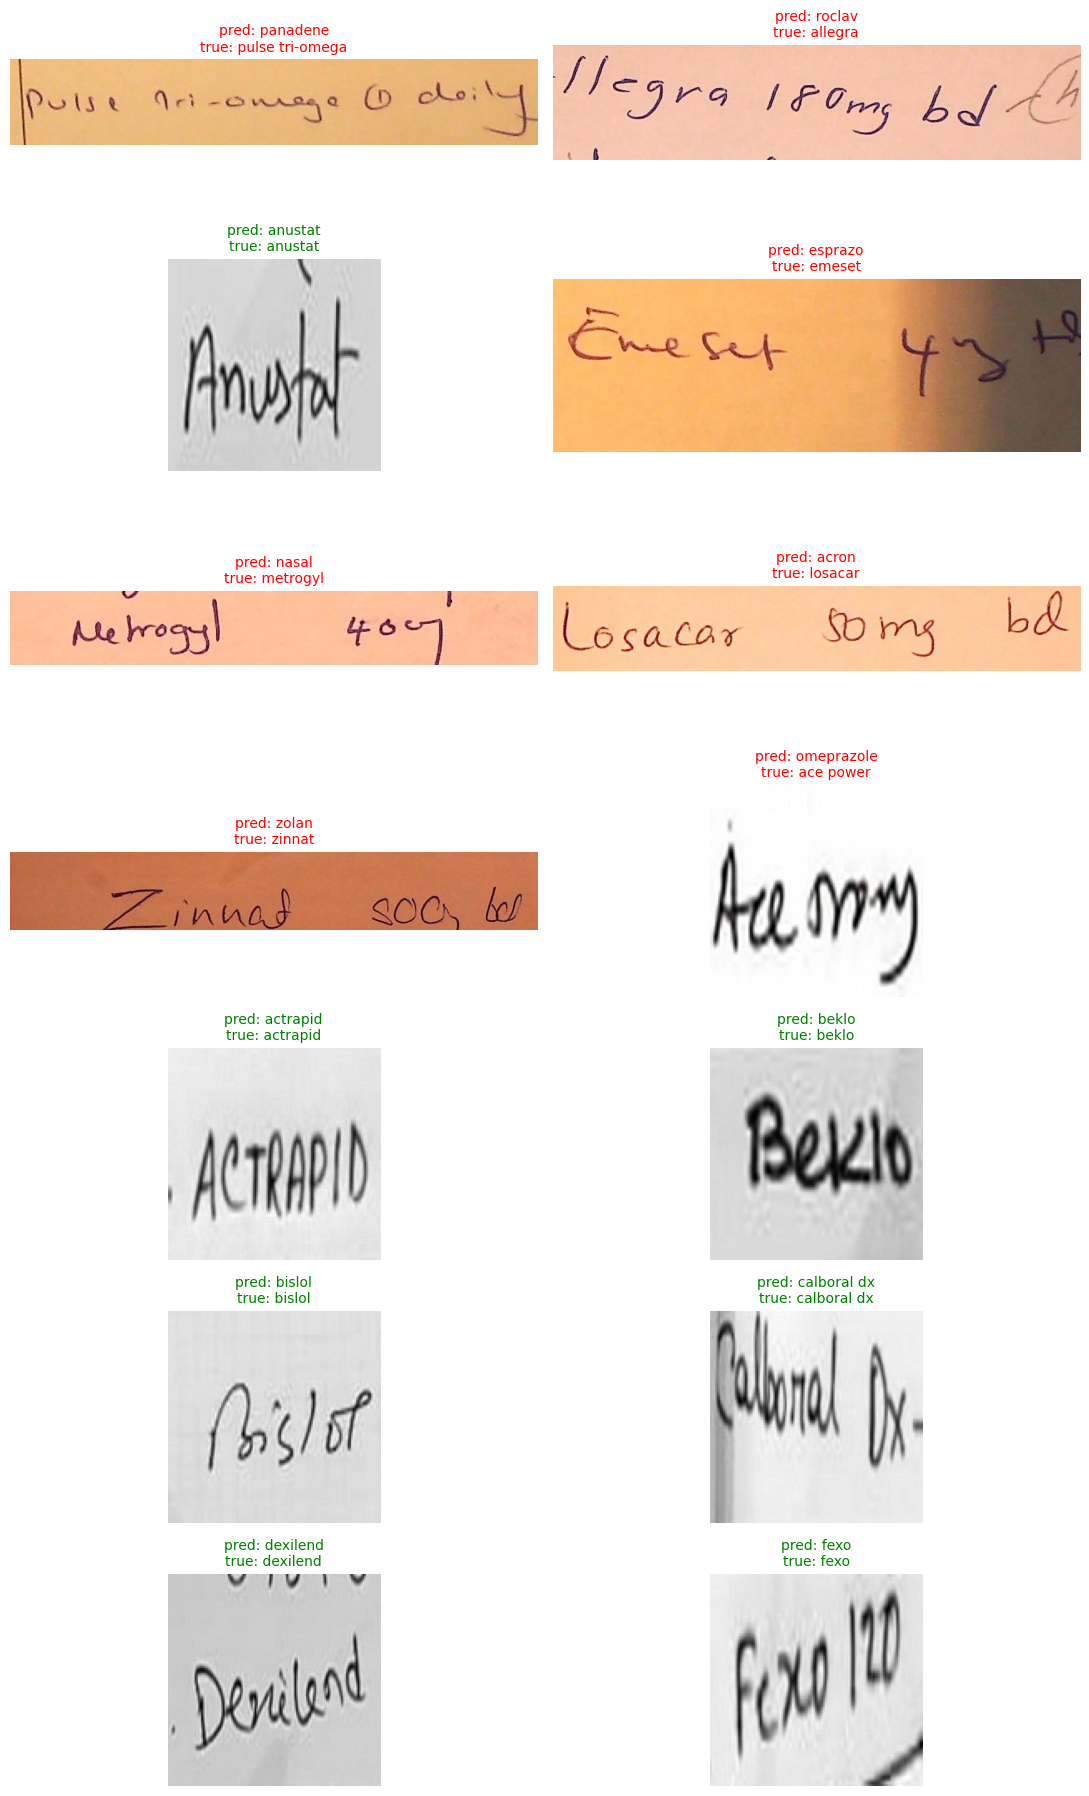


saved -> ../data/pharmacy_lk/chosen_predictions.csv


In [24]:
CHOSEN_IMAGES = [
    "173109_0_med_7.jpg",
    "173233_0_med_1.jpg",
    "192879_1_med_1.jpg",
    "173478_0_med_2.jpg",
    "174239_0_med_2.jpg",
    "174327_0_med_1.jpg",
    "175321_1_med_1.jpg",
    "192615_0_med_0.jpg",
    "192632_0_med_3.jpg",
    "193018_2_med_0.jpg",
    "193115_1_med_0.jpg",
    "193264_0_med_0.jpg",
    "193845_0_med_0.jpg",
    "194606_2_med_0.jpg"

    
]

# Build a filename -> true label lookup across ALL splits (so any image resolves)
_label_lookup = {}
for _split in ["splits/train.csv", "splits/val.csv", "splits/test.csv"]:
    _pth = DATA_ROOT / _split
    if _pth.exists():
        _df = pd.read_csv(_pth)
        for _, _r in _df.iterrows():
            _label_lookup[str(_r["image_filename"])] = str(_r[LABEL_COL]).strip().lower()

rows_out = []
panels = []
for fname in CHOSEN_IMAGES:
    img_p = DATA_ROOT / "images" / fname
    if not img_p.exists():
        print(f"  [missing image] {fname}")
        continue
    pil = Image.open(img_p)
    pred = fusion_predict(pil, verbose=False)
    true = _label_lookup.get(fname, "(no annotation found)")
    ok = (pred == true)
    rows_out.append({"image": fname, "predicted": pred, "true": true, "correct": ok})
    panels.append((pil, pred, true, ok))
    mark = "CORRECT" if ok else "wrong"
    print(f"  {fname:32s} | pred: {pred:18s} | true: {true:18s} | {mark}")

# visual: each image with predicted + true name
if panels:
    n = len(panels); cols = 2; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5.5, rows*2.6))
    axes = np.array(axes).reshape(-1)
    for ax, (pil, pred, true, ok) in zip(axes, panels):
        ax.imshow(pil, cmap="gray"); ax.axis("off")
        colour = "green" if ok else "red"
        ax.set_title(f"pred: {pred}\ntrue: {true}", fontsize=10, color=colour)
    for ax in axes[len(panels):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()
    pd.DataFrame(rows_out).to_csv(DATA_ROOT / "chosen_predictions.csv", index=False)
    print(f"\nsaved -> {DATA_ROOT / 'chosen_predictions.csv'}")
else:
    print("No images to show — add filenames to CHOSEN_IMAGES above.")